In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
import PIL
import tensorflow as tf
from tensorflow.keras.applications import VGG16
import kagglehub
import random
import shutil

**Problem Statement:**

The categorization of images into distinct classes is a pervasive task in computer
vision, and it has a wide array of applications, including in pet identification and
animal monitoring systems. In this assignment, we aim to develop a model
capable of accurately distinguishing between cat and dog images. Instead of
building a convolutional neural network (CNN) from scratch, we will leverage
transfer learning using the VGG16 model, a pre-trained model on the ImageNet
dataset. VGG16 is renowned for its effectiveness in image recognition tasks, but
it does not have broad categories for cats and dogs. Therefore, we will utilize the
convolutional (Conv) layers of VGG16 for feature extraction and add custom fully
connected (Cat) layers for the classification task.


In [2]:
KPATH = kagglehub.dataset_download('shaunthesheep/microsoft-catsvsdogs-dataset')
KPATH = os.path.join(KPATH, 'PetImages')
print(KPATH)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
/kaggle/input/microsoft-catsvsdogs-dataset/PetImages


In [3]:
try:
  shutil.copytree(KPATH, 'content/PetImages')
except FileExistsError:
  print('file already copied, process continued')
except:
  print('Please manualy set directory and files if different environment')
  raise # Re-raises the original exception with original traceback

In [4]:
KPATH = 'content/PetImages'
assert KPATH

**Data Preprocessing and Augmentation:**

Implement image data generators for real-time data augmentation, ensuring a
robust and varied dataset for training the classification layers.


In [5]:
for f in os.listdir(os.path.join(KPATH, 'Cat')):
  try:
    # print(f)
    #check able to open and not corrupted
    PIL.Image.open(os.path.join(KPATH, 'Cat', f))

    #check it is corrupted or header malformed, to fix error :    Input size should match (header_size + row_size * abs_height)
    tf.io.decode_image(
        tf.io.read_file(os.path.join(KPATH, 'Cat', f)), # readed as raw bits string
        channels=3, expand_animations=False
    )

    #check shape and channel is as expected
    img = cv2.imread(os.path.join(KPATH, 'Cat', f))
    assert img.ndim == 3 and img.shape[-1] == 3
  except Exception as e:
    print(f, e)
    if os.path.exists(os.path.join(KPATH, 'Cat', f)):
       os.remove(os.path.join(KPATH, 'Cat', f))

for f in os.listdir(os.path.join(KPATH, 'Dog')):
  try:
    PIL.Image.open(os.path.join(KPATH, 'Dog', f))

    #check it is corrupted or header malformed, to fix error :    Input size should match (header_size + row_size * abs_height)
    tf.io.decode_image(
        tf.io.read_file(os.path.join(KPATH, 'Dog', f)),
        channels=3, expand_animations=False
    )

    img = cv2.imread(os.path.join(KPATH, 'Dog', f))
    assert img.ndim == 3 and img.shape[-1] == 3
  except Exception as e:
    print(f, e)
    if os.path.exists(os.path.join(KPATH, 'Dog', f)):
       os.remove(os.path.join(KPATH, 'Dog', f))

# can generalize with "for root, dirs, files in os.walk(dataset_path):" instead of hardcode directory

10404.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Unknown image file format. One of JPEG, PNG, GIF, BMP required. [Op:DecodeImage] name: 
Thumbs.db cannot identify image file 'content/PetImages/Cat/Thumbs.db'
666.jpg cannot identify image file 'content/PetImages/Cat/666.jpg'
4351.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
2494.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Input size should match (header_size + row_size * abs_height) but they differ by 2 [Op:DecodeImage] name: 
11912.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


11233.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
2317.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
Thumbs.db cannot identify image file 'content/PetImages/Dog/Thumbs.db'
9500.jpg {{function_node __wrapped__DecodeImage_device_/job:localhost/replica:0/task:0/device:CPU:0}} Number of channels inherent in the image must be 1, 3 or 4, was 2 [Op:DecodeImage] name: 
11702.jpg cannot identify image file 'content/PetImages/Dog/11702.jpg'


In [6]:
LABELS = ['Cat', 'Dog']
IMAGE_SIZE = (150, 150)
BATCH_SIZE = 32

In [7]:
# train_idg = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1/255,
#     rotation_range=20,
#     shear_range=0.2,
#     horizontal_flip=True,
#     validation_split=0.2
# )

# test_idg = tf.keras.preprocessing.image.ImageDataGenerator(
#     rescale=1/255,
#     validation_split=0.2
# )

# train_gen = train_idg.flow_from_directory(
#     KPATH,
#     target_size=IMAGE_SIZE,
#     batch_size=32,
#     class_mode='binary', #'categorical'
#     subset='training',
#     seed=42,
#     shuffle=True,
# )

# test_gen = test_idg.flow_from_directory(
#     KPATH,
#     target_size=IMAGE_SIZE,
#     batch_size=32,
#     class_mode='binary', # 'categorical'
#     subset='validation',
#     shuffle=False,
#     seed=42,

# )

# validation split option seems work only with same data-generator , since require different datagenerator for traing and test as agumentation only for training. Also, ImageDataGenerator is DEBRICATED better move to image_data_from_directory latest approach.


In [8]:
train_data = tf.keras.utils.image_dataset_from_directory(
    KPATH,
    batch_size=BATCH_SIZE,
    image_size=(152, 152),
    # image_mode='rgb', #convert to 3 channel, its default
    # labels='inferred', # default,automaticaly define lables based on subfolder
    subset='training',
    validation_split=0.2,
    seed=42,
    shuffle=True,
)

test_data = tf.keras.utils.image_dataset_from_directory(
    KPATH,
    batch_size=BATCH_SIZE,
    image_size=(152, 152),
    # image_mode='rgb',
    subset='validation',
    validation_split=0.2,
    seed=42,
    shuffle=True,
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


rescaling not require since VGG16 expecting 0-255 values.

In [9]:
#prefetch and parallel codeing
train_data = train_data.cache().prefetch(tf.data.AUTOTUNE)
test_data = test_data.cache().prefetch(tf.data.AUTOTUNE)

**Build and Train the Classification Model:**

● Add custom fully connected layers on top of the VGG16 model for the classification task.

● Freeze the convolutional layers of VGG16 to retain the pre-trained features and only train the added classification layers.


In [10]:
""""
include_top: whether to include the 3 fully-connected
        layers at the top of the network.
weights: one of `None` (random initialization),
        `"imagenet"` (pre-training on ImageNet),
        or the path to the weights file to be loaded.
input_shape:
"""
base_model = VGG16(
    include_top=False,
    weights='imagenet', # pre-trained weights
    input_shape=(152, 152, 3)
)

# stop retraining , freez the layers
for l in base_model.layers:
  l.trainable = False

# base_model.trainable = False
# base_model.layers

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Model Compilation and Training:**

● Compile the model using stochastic gradient descent, categorical cross-entropy as the loss function, and accuracy as the evaluation metric.

●Train the model using the training data, and validate its performance using a validation set.


In [11]:
#built custom classification layers
x = base_model.output #output layer values of vgg1, it is ip for custom layers
x = tf.keras.layers.Flatten()(x)  # callable objects __call__ thunder function.
x = tf.keras.layers.Dense(units=256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(units=2, activation='softmax')(x)
# output = tf.keras.layers.Dense(units=1, activation='sigmoid'


In [12]:
model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=output)

In [13]:
# compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.sparse_categorical_crossentropy, #sparse_categorical_crossentropy,
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    train_data,
    epochs=3,
    validation_data=test_data
)

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 7692s 12s/step - accuracy: 0.9221 - loss: 0.8863 - val_accuracy: 0.9450 - val_loss: 0.1400
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 7715s 12s/step - accuracy: 0.9537 - loss: 0.1374 - val_accuracy: 0.9534 - val_loss: 0.1398
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 7715s 12s/step - accuracy: 0.9552 - loss: 0.1262 - val_accuracy: 0.9436 - val_loss: 0.1941


**Evaluate and Test the Model:**

● Assess the model's performance based on its accuracy in classifying images into cat or dog categories.

● Implement a prediction function to classify new images, providing the predicted category and the associated confidence level.

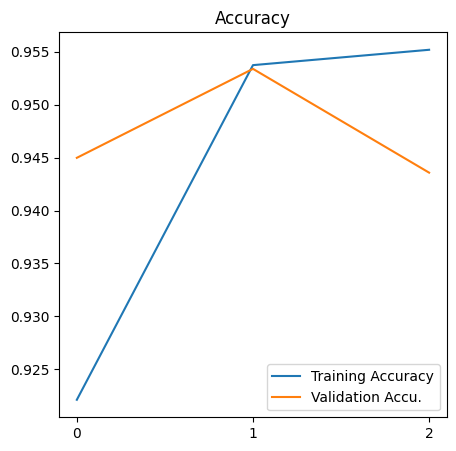

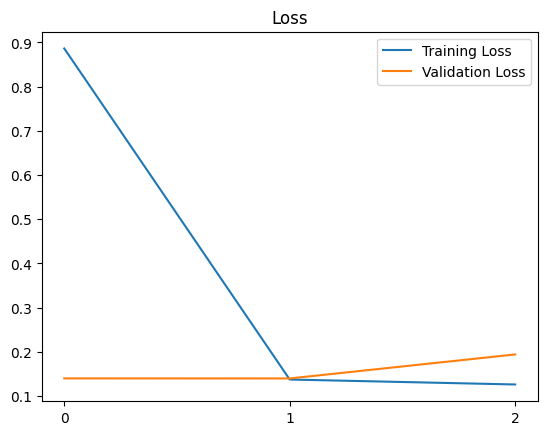

In [23]:
#plot result
plt.figure(figsize=(5,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accu.')
plt.xticks([0,1,2])
plt.title('Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xticks([0,1,2])
plt.title('Loss')
plt.legend()
plt.show()


In [16]:
#evaluate
model.evaluate(test_data.take(5))

5/5 ━━━━━━━━━━━━━━━━━━━━ 50s 10s/step - accuracy: 0.9312 - loss: 0.2389


[0.23885318636894226, 0.9312499761581421]

In [17]:
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 152, 152, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [18]:
# [*test_data.take(1)] # each take fetch set of 32 images, because batch_size is 32.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 570ms/step


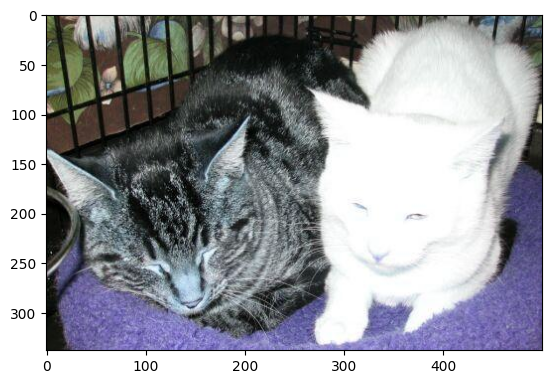

In [19]:
# # predict - read image from file and convert to bits and predict
img_file = random.sample(os.listdir(os.path.join(KPATH, 'Cat')), 1)[0]
img_file = os.path.join(KPATH, 'Cat', img_file)
img = cv2.imread(img_file)
plt.imshow(img)
img = tf.expand_dims(cv2.resize(img, (152, 152)), axis=0)
pred_lab = model.predict(img)
#   print(lab, pred_lab)

In [20]:
pred_lab

array([[9.9998868e-01, 1.1333078e-05]], dtype=float32)

In [21]:
LABELS[np.argmax(pred_lab)]

'Cat'